In [168]:
import cellwhisperer
from cellwhisperer.config import get_path
import pandas as pd
from geneformer.tokenizer import TranscriptomeTokenizer, rank_genes
from cellwhisperer.jointemb.geneformer_model import GeneformerTranscriptomeProcessor
import numpy as np
import scanpy as sc

TODOs

- test for another dataset (tabsap100 cell types)
- test for np.log2

In [4]:
import anndata

In [161]:
# Load `human_disease` dataset

adata = anndata.read_h5ad(get_path(["paths", "read_count_table"], dataset="human_disease"))  # human_disease
# adata.var["ensembl_id"] = adata.var["gene_id"].apply(lambda v: v[:v.find(".")])

In [162]:
processor = GeneformerTranscriptomeProcessor(1, "gene_name")
processed = processor(adata)

In [163]:
reverse_dict = {v: k for k, v in processor.tokenizer.gene_token_dict.items()}

In [164]:
top_genes = [reverse_dict.get(tid) for tid in processed["expression_tokens"][0]]
len(set(top_genes) & set(hvgs.loc[hvgs.isPredicted, "ensembl_id"].values))

550

In [165]:
overlaps = []
hvg_set = set(hvgs.loc[hvgs.isPredicted, "ensembl_id"].values)

for cell in processed["expression_tokens"]:
    top_genes = [reverse_dict.get(tid) for tid in cell]
    overlaps.append(len(set(top_genes) & hvg_set))

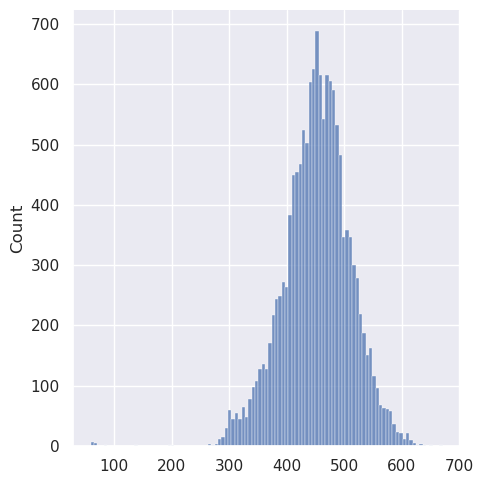

In [166]:
import seaborn as sns
sns.displot(overlaps)

In [239]:
# Load `human_disease` dataset

adata = anndata.read_h5ad(get_path(["paths", "read_count_table"], dataset="tabula_sapiens_100_cells_per_type"))
adata.var["ensembl_id"] = adata.var.index.map(lambda v: v[:v.find(".")])


In [243]:
adata.X.max()

8.930615

In [242]:
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata) #flavor seurat to allow raw read counts

In [ ]:
hvgs.set_index("ensembl_id")["variances"]

In [231]:
adata.var.set_index("ensembl_id")["dispersions"]

ensembl_id
ENSG00000223972   -1.284442
ENSG00000227232    1.555942
ENSG00000278267   -0.706505
ENSG00000243485    0.478387
ENSG00000284332         NaN
                     ...   
ENSG00000198695    2.257368
ENSG00000210194    1.201946
ENSG00000198727    4.978623
ENSG00000210195    0.531537
ENSG00000210196    2.432378
Name: dispersions, Length: 58870, dtype: float64

In [232]:
vars

,adata,deepspot_hvgs
ensembl_id,,
ENSG00000223972,3.207676,NaN
ENSG00000227232,3.906443,NaN
ENSG00000278267,2.076900,NaN
ENSG00000243485,2.736444,NaN
ENSG00000237613,2.260437,NaN
...,...,...
ENSG00000276017,3.869998,NaN
ENSG00000278817,4.718284,NaN
ENSG00000277196,5.723149,NaN


In [233]:
vars = pd.DataFrame(
            index=adata.var.ensembl_id
            )
vars["adata"] = adata.var.set_index("ensembl_id")["dispersions"]
vars["deepspot_hvgs"] = hvgs.set_index("ensembl_id")["variances_norm"].loc[~hvgs.set_index("ensembl_id").index.duplicated(keep='first')]

vars = vars.loc[~vars.index.duplicated(keep="first")]

In [234]:
vars.dropna()

,adata,deepspot_hvgs
ensembl_id,,
ENSG00000187634,1.305140,1.025874
ENSG00000188976,0.565110,1.027006
ENSG00000187961,0.817457,0.958920
ENSG00000187583,0.592553,0.977627
ENSG00000187642,0.734163,1.023445
...,...,...
ENSG00000155959,1.192753,0.975712
ENSG00000155961,1.171570,0.942263
ENSG00000155962,1.051106,1.053353


<Axes: xlabel='adata', ylabel='deepspot_hvgs'>

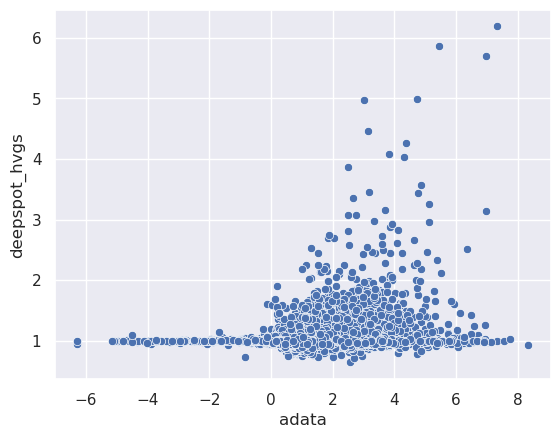

In [235]:
sns.scatterplot(data=vars.dropna(), x="adata", y="deepspot_hvgs")

In [186]:
sns.scatterplot(x=adata.var.set_index("ensembl_id")["dispersions"], y=hvgs.set_index("ensembl_id")["variances"])

/msc/home/mschae83/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/seaborn/_core/data.py:265: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  frame = pd.DataFrame(plot_data)


ValueError: cannot reindex on an axis with duplicate labels

In [181]:
adata.var.iloc[0]

chr                                     chr1
start                                  11869
end                                    13670
strand                                     +
length                                  1735
gene_id                    ENSG00000223972.5
gene_name                            DDX11L1
salmon_length                         1657.0
salmon_effective_length              1501.24
ensembl_id                   ENSG00000223972
highly_variable                        False
means                                0.40667
dispersions                         3.207676
dispersions_norm                   -0.258542
Name: ENSG00000223972.5, dtype: object

<Axes: xlabel='dispersions', ylabel='dispersions_norm'>

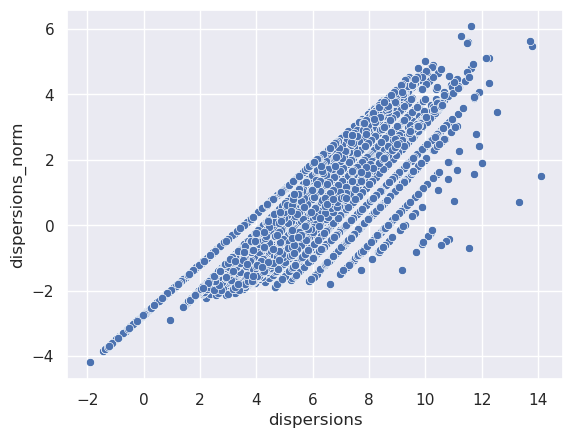

In [179]:
sns.scatterplot(adata.var, x="dispersions", y="dispersions_norm"

In [ ]:
# TODO compare variances (scatterplot)
sns.scatterplot

In [72]:
gene_name2ensembl_id = adata.var.set_index("gene_name")["ensembl_id"].drop_duplicates()
gene_name2ensembl_id = gene_name2ensembl_id[~gene_name2ensembl_id.index.duplicated(keep='first')].dropna()

In [73]:
hvgs = pd.read_csv("info_highly_variable_genes.csv")  # https://github.com/user-attachments/files/19116146/info_highly_variable_genes.csv
hvgs["ensembl_id"] = hvgs["gene_name"].apply(gene_name2ensembl_id)
hvgs

,gene_name,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,variances_norm_rank,isPresentInAll,isPredicted,ensembl_id
0,PRDM16,True,8147.0,0.051796,0.057279,1.002311,18.0,7809.0,True,False,ENSG00000142611
1,PEX10,True,4936.0,0.572528,0.795817,1.004117,18.0,3349.0,True,True,ENSG00000157911
2,PEX14,True,11143.0,0.591971,0.796079,0.953862,18.0,11753.0,True,False,ENSG00000142655
3,PLCH2,True,5607.5,0.180320,0.246743,1.026949,18.0,4307.0,True,True,ENSG00000149527
4,SPSB1,True,2586.0,1.898239,4.812148,1.057293,18.0,1730.0,True,True,ENSG00000171621
...,...,...,...,...,...,...,...,...,...,...,...
19333,MT-ND4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,ENSG00000198886
19334,MT-ND5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,ENSG00000198786
19335,MT-ND6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,ENSG00000198695
19336,MT-CYB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,ENSG00000198727


In [74]:
viable_genes = set(hvgs.ensembl_id.tolist()) & set(tokenizer.gene_median_dict.keys())

# adata.var["ensembl_id"] = adata.var.gene_name.apply(tokenizer.gene_median_dict.get)
adata = adata[:, adata.var.ensembl_id.isin(viablue_genes)].copy()


In [78]:
adata.var["ensembl_id"] = adata.var["gene_id"].apply(lambda v: v[:v.find(".")])

In [79]:
hvgs

,gene_name,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,variances_norm_rank,isPresentInAll,isPredicted,ensembl_id
0,PRDM16,True,8147.0,0.051796,0.057279,1.002311,18.0,7809.0,True,False,ENSG00000142611
1,PEX10,True,4936.0,0.572528,0.795817,1.004117,18.0,3349.0,True,True,ENSG00000157911
2,PEX14,True,11143.0,0.591971,0.796079,0.953862,18.0,11753.0,True,False,ENSG00000142655
3,PLCH2,True,5607.5,0.180320,0.246743,1.026949,18.0,4307.0,True,True,ENSG00000149527
4,SPSB1,True,2586.0,1.898239,4.812148,1.057293,18.0,1730.0,True,True,ENSG00000171621
...,...,...,...,...,...,...,...,...,...,...,...
19333,MT-ND4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,ENSG00000198886
19334,MT-ND5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,ENSG00000198786
19335,MT-ND6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,ENSG00000198695
19336,MT-CYB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,ENSG00000198727


In [133]:
hvgs.loc[hvgs.isPredicted, "ensembl_id"].values

array(['ENSG00000157911', 'ENSG00000149527', 'ENSG00000171621', ...,
       'ENSG00000159200', 'ENSG00000171189', 'ENSG00000142173'],
      dtype=object)

In [95]:
X = adata.X.toarray()


norm_factor_vector = adata.var["ensembl_id"].apply(tokenizer.gene_median_dict.get).values.astype(float)


In [97]:
X.max()

4237434

In [94]:
normed_X = X / norm_factor_vector

In [100]:
normed_X.shape

(14112, 18842)

In [107]:
normed_X.mean(axis=1).std()  # mhh. ideal would be ~0?

161.27143314319872

In [106]:
X.mean(axis=1).std()

528.0011900255023

In [108]:
normed_X

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.29551311e+00, 6.54268211e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        8.49280814e+00, 7.30599502e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        3.02286392e+00, 3.25316694e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        4.53587928e+03, 1.41005704e+03, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.04792616e+02, 3.13867000e+01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        8.21931093e+01, 2.01550957e+01, 0.00000000e+00]])

In [110]:
adata.obs

,featurecounts_Percent_Assigned_,featurecounts_Percent_Duplicates,featurecounts_Percent_Assigned_O,featurecounts_Percent_Assigned_M,featurecounts_Percent_Assigned_MO,sra_study_acc,bio_project_acc,Tissue,Tissue_subtype,Disease,...,star_percent_unmapped_reads_too_many_loci,star_number_unmapped_reads_too_many_mismatches,star_percent_unmapped_reads_too_many_mismatches,star_number_unmapped_reads_too_short,star_percent_unmapped_reads_too_short,star_number_unmapped_reads_other,star_percent_unmapped_reads_other,star_number_chimeric_reads,star_percent_chimeric_reads,has_salmon_quantification
SRX114770,0.412,8.344,0.478,10.996,12.970,SRP010181,Rob_Research_Colon,Bowel,Colon,Colorectal cancer,...,3.42,0.0,0.0,108620.0,4.70,43035.0,1.86,0.0,0.0,False
SRX085327,2.839,11.003,3.068,9.893,10.397,SRP007584,Rob_Research_Fusobacterium,Bowel,Colon,Healthy,...,0.49,0.0,0.0,87782.0,4.78,28345.0,1.54,0.0,0.0,False
SRX114769,1.292,8.534,1.451,10.552,11.995,SRP010181,Rob_Research_Colon,Bowel,Colon,Colorectal cancer,...,3.29,0.0,0.0,205997.0,7.38,54319.0,1.95,0.0,0.0,False
SRX085326,4.784,11.779,5.121,8.895,9.465,SRP007584,Rob_Research_Fusobacterium,Bowel,Colon,Healthy,...,0.43,0.0,0.0,101968.0,4.23,28139.0,1.17,0.0,0.0,False
SRX085322,4.313,10.802,4.697,9.126,10.039,SRP007584,Rob_Research_Fusobacterium,Bowel,Colon,Healthy,...,0.67,0.0,0.0,275881.0,10.76,251730.0,9.82,0.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRX8297318,15.056,38.248,16.332,36.125,45.052,SRP192421,GSE129752,Blood,NaN,Antineutrophil cytoplasmic antibody associated...,...,0.25,0.0,0.0,3779.0,0.20,82377.0,4.38,0.0,0.0,False
SRX8297319,18.349,43.857,19.876,37.830,45.116,SRP192421,GSE129752,Blood,NaN,Antineutrophil cytoplasmic antibody associated...,...,0.02,0.0,0.0,25155.0,0.35,3532.0,0.05,0.0,0.0,False
SRX982255,34.361,38.966,37.462,49.651,53.826,SRP056956,PRJNA280563,Brain,Hippocampus,Epilepsy,...,0.00,0.0,0.0,17211785.0,53.77,8504.0,0.03,0.0,0.0,False
SRX9686493,11.079,29.021,11.844,16.721,18.547,SRP223384,GSE138042,Thyroid gland,NaN,Thyroid cancer,...,0.12,0.0,0.0,605800.0,1.16,172938.0,0.33,0.0,0.0,False


In [ ]:
X_view = prepared_features[idx, coding_and_miRNA_loc].X

X_norm = X / n_counts * target_sum / norm_factor_vector

X_norm = sp.csr_matrix(X_norm)

tokenized_cells += [
rank_genes(X_norm[i].data, coding_miRNA_tokens[X_norm[i].indices])
for i in range(X_norm.shape[0])
]


In [36]:
annot = pd.read_csv(
    get_path(["paths", "ensembl_gene_symbol_map"]), index_col=0
)
annot

,ensembl_gene_id
external_gene_name,
MT-TF,ENSG00000210049
MT-RNR1,ENSG00000211459
MT-TV,ENSG00000210077
MT-RNR2,ENSG00000210082
MT-TL1,ENSG00000209082
...,...
LINC01705,ENSG00000232679
RNU6-403P,ENSG00000200033
LINC02474,ENSG00000228437


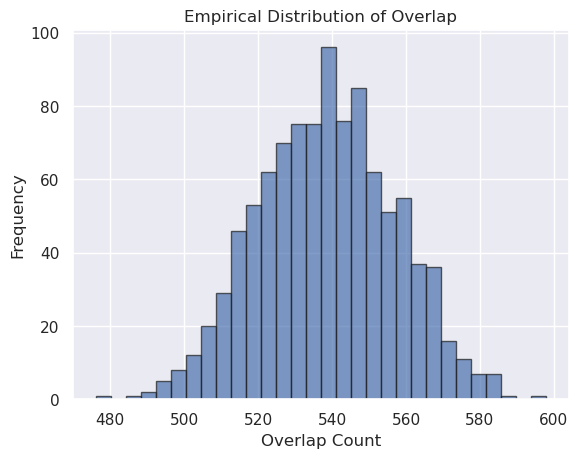

In [160]:

import numpy as np
import matplotlib.pyplot as plt

# Parameters
total_genes = 19000
first_sample_size = 5000
second_sample_size = 2048
num_simulations = 1000  # Number of simulations for the empirical distribution
genes = np.arange(total_genes)
# Simulate the process
overlaps = []
for _ in range(num_simulations):
    first_sample = np.random.choice(genes, size=first_sample_size, replace=False)
    second_sample = np.random.choice(genes, size=second_sample_size, replace=False)
    overlap = len(set(first_sample) & set(second_sample))
    overlaps.append(overlap)

# Plot the empirical distribution
plt.hist(overlaps, bins=30, edgecolor='k', alpha=0.7)
plt.title('Empirical Distribution of Overlap')
plt.xlabel('Overlap Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
